In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/skris/Downloads/AI_Healthcare_Heart_Disease/datasets/heart_disease_clean.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully!
Shape: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,disease_status
0,63,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0,No Heart Disease
1,67,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1,Heart Disease
2,67,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1,Heart Disease
3,37,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0,No Heart Disease
4,41,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0,No Heart Disease


In [5]:
print("Number of patients:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Number of patients: 303
Number of columns: 15

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'disease_status']

Data types:
age                 int64
sex                 int64
cp                  int64
trestbps          float64
chol              float64
fbs                 int64
restecg             int64
thalach           float64
exang               int64
oldpeak           float64
slope               int64
ca                  int64
thal                int64
target              int64
disease_status     object
dtype: object


In [7]:
display(df.describe())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


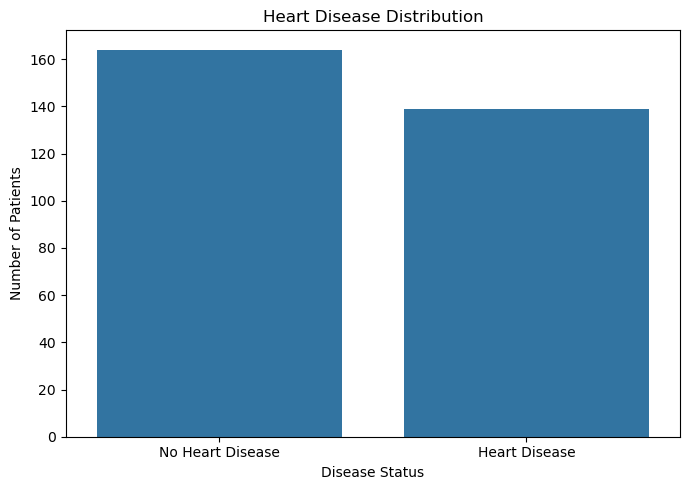

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="disease_status"
)

plt.title("Heart Disease Distribution")
plt.xlabel("Disease Status")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

disease_status
No Heart Disease    54.13
Heart Disease       45.87
Name: proportion, dtype: float64


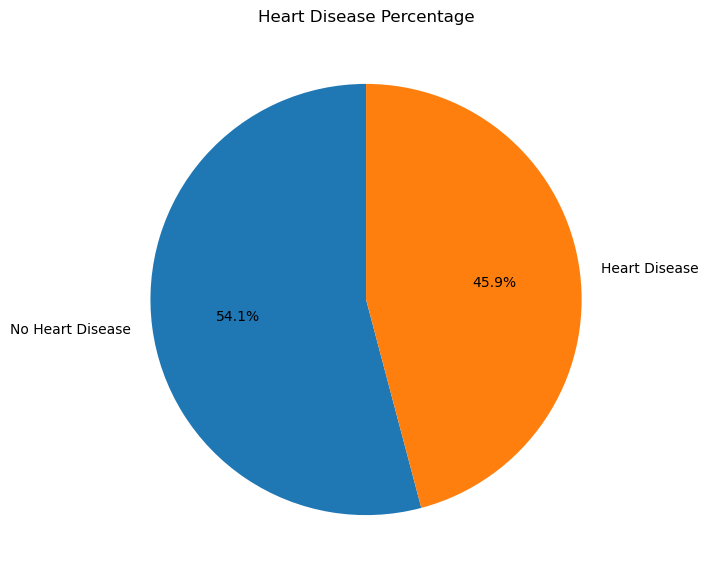

In [15]:
target_percentage = (
    df["disease_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print(target_percentage)
plt.figure(figsize=(7, 7))
df["disease_status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Heart Disease Percentage")
plt.ylabel("")
plt.show()

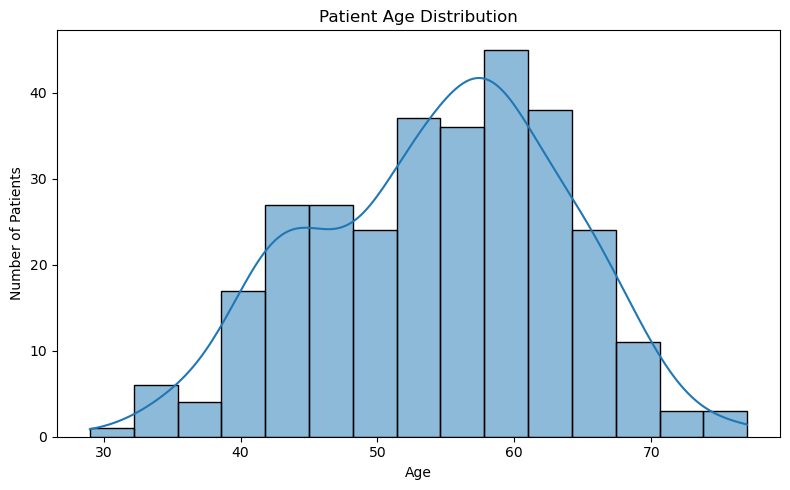

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="age",
    bins=15,
    kde=True
)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

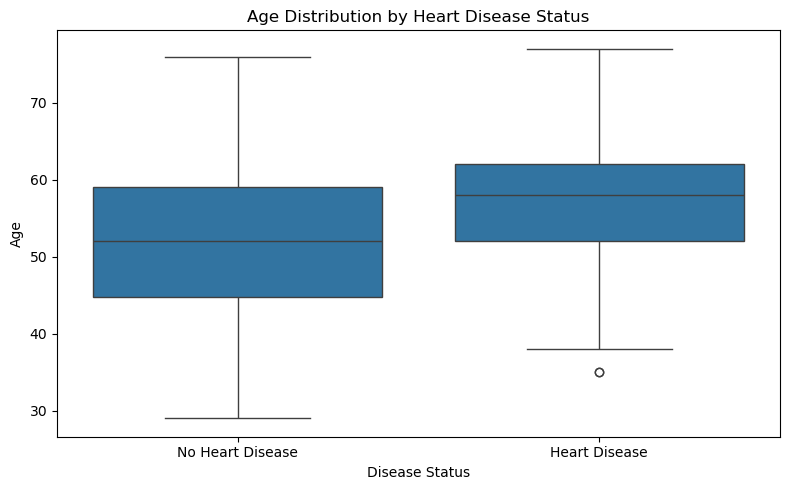

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="disease_status",
    y="age"
)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [21]:
df["gender"] = df["sex"].map({
    0: "Female",
    1: "Male"
})

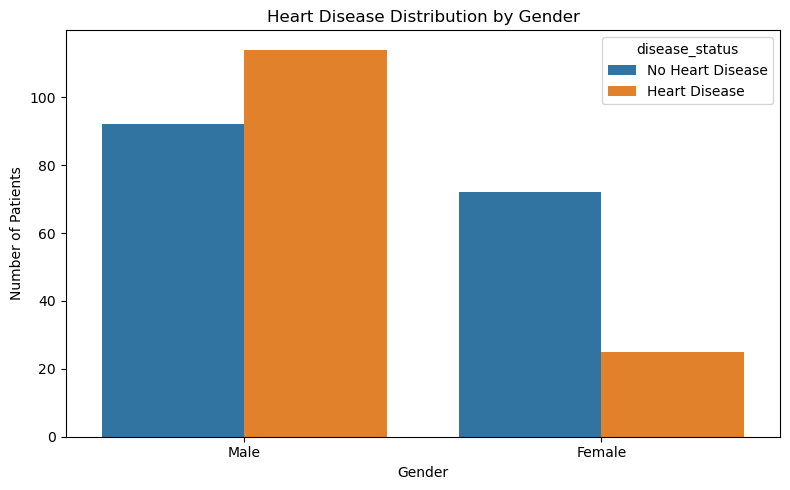

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="gender",
    hue="disease_status"
)
plt.title("Heart Disease Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

In [25]:
gender_disease_rate = pd.crosstab(
    df["gender"],
    df["target"],
    normalize="index"
) * 100
print(gender_disease_rate.round(2))

target      0      1
gender              
Female  74.23  25.77
Male    44.66  55.34


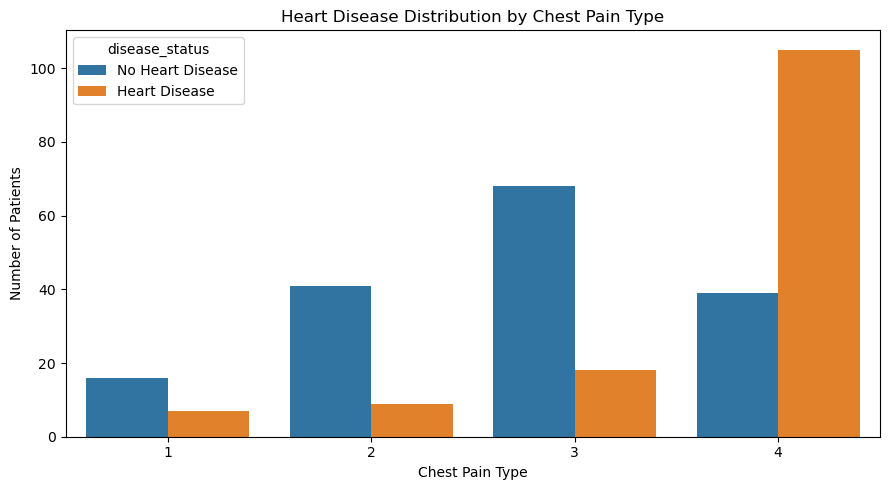

In [29]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="cp",
    hue="disease_status"
)
plt.title("Heart Disease Distribution by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

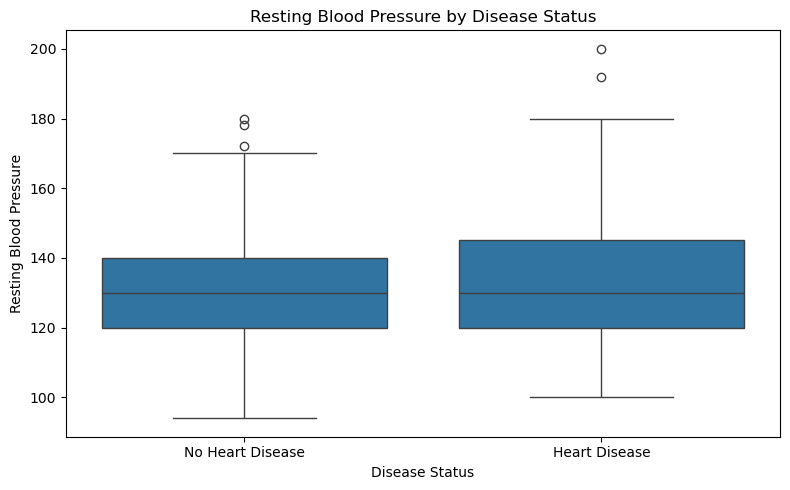

In [31]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="disease_status",
    y="trestbps"
)
plt.title("Resting Blood Pressure by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Resting Blood Pressure")
plt.tight_layout()
plt.show()

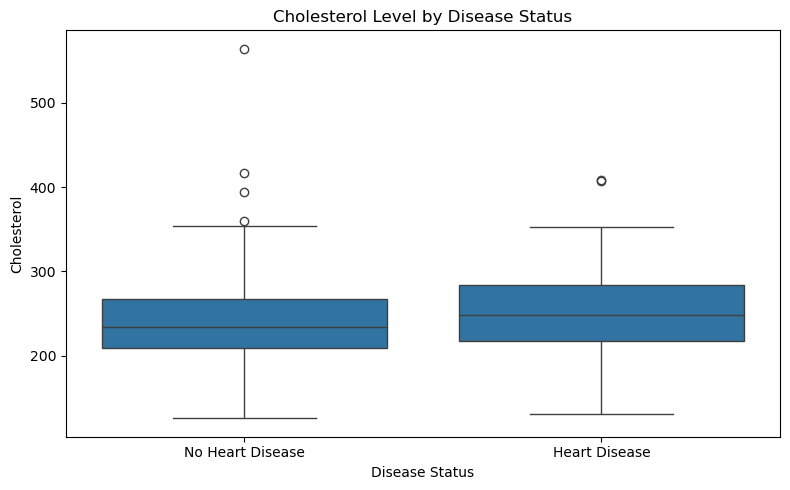

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="disease_status",
    y="chol"
)
plt.title("Cholesterol Level by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Cholesterol")
plt.tight_layout()
plt.show()

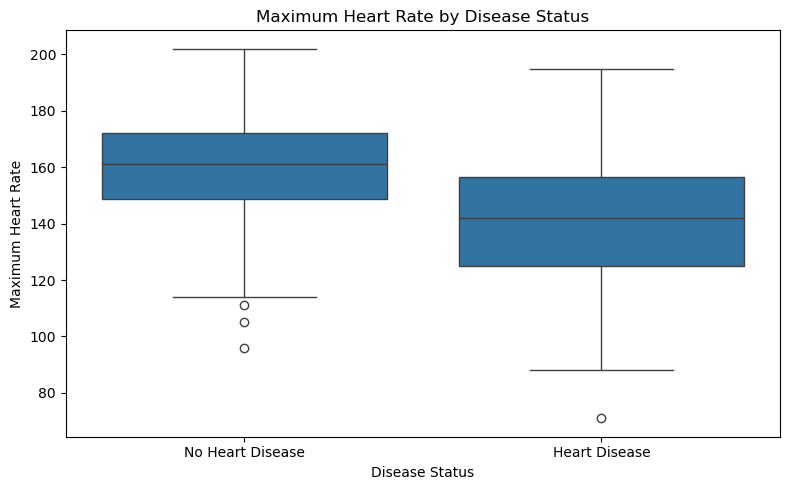

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="disease_status",
    y="thalach"
)
plt.title("Maximum Heart Rate by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Maximum Heart Rate")
plt.tight_layout()
plt.show()

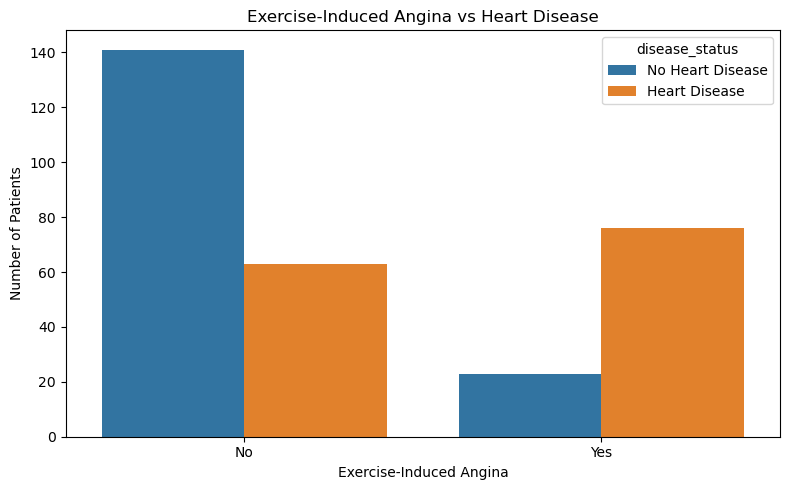

In [37]:
df["exercise_angina"] = df["exang"].map({
    0: "No",
    1: "Yes"
})
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="exercise_angina",
    hue="disease_status"
)
plt.title("Exercise-Induced Angina vs Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

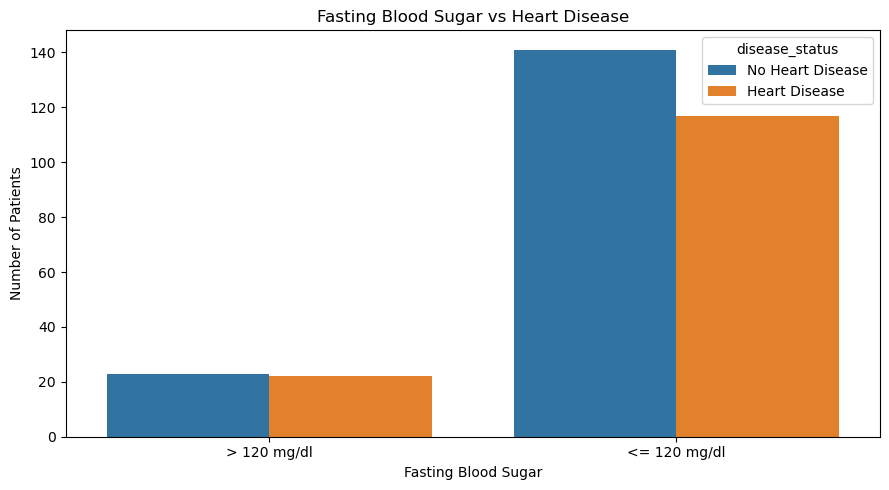

In [39]:
df["fasting_blood_sugar"] = df["fbs"].map({
    0: "<= 120 mg/dl",
    1: "> 120 mg/dl"
})
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="fasting_blood_sugar",
    hue="disease_status"
)
plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("Fasting Blood Sugar")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

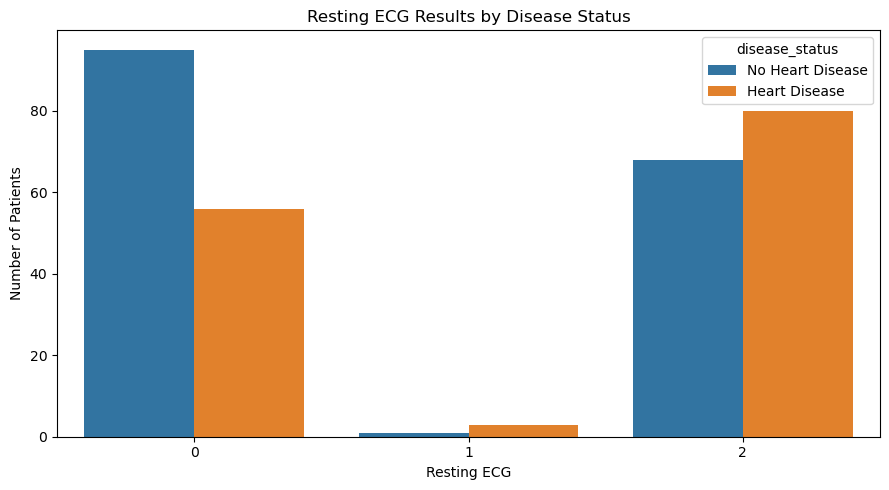

In [41]:
plt.figure(figsize=(9, 5))
sns.countplot(
    data=df,
    x="restecg",
    hue="disease_status"
)
plt.title("Resting ECG Results by Disease Status")
plt.xlabel("Resting ECG")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

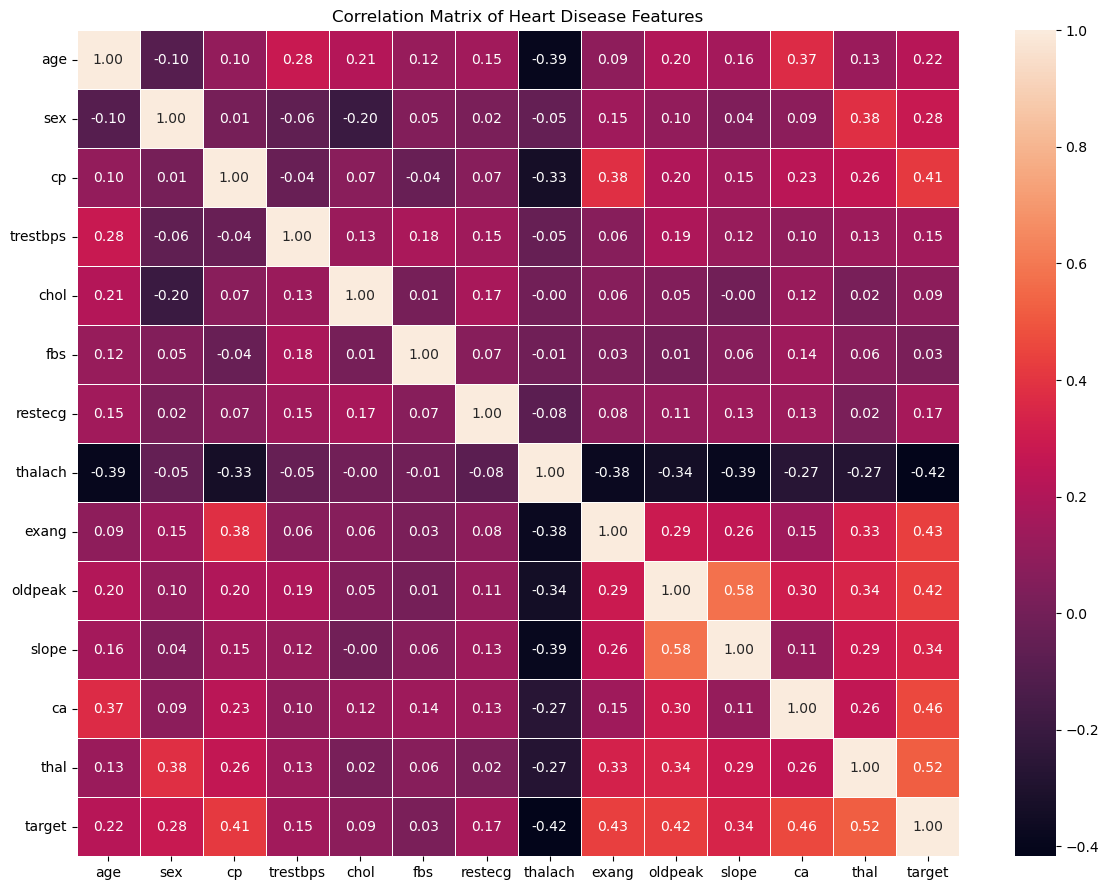

In [43]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)
plt.figure(figsize=(12, 9))
correlation = numeric_df.corr()
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix of Heart Disease Features")
plt.tight_layout()
plt.show()

In [46]:
target_correlation = (
    numeric_df.corr()["target"]
    .sort_values(
        ascending=False
    )
)
print(target_correlation)

target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [50]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 39, 49, 59, 69, 100],
    labels=[
        "Under 40",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]
)
print(df["age_group"].value_counts().sort_index())

age_group
Under 40     15
40-49        72
50-59       125
60-69        81
70+          10
Name: count, dtype: int64


           total_patients  disease_patients  disease_rate
age_group                                                
Under 40               15                 4         26.67
40-49                  72                22         30.56
50-59                 125                60         48.00
60-69                  81                49         60.49
70+                    10                 4         40.00


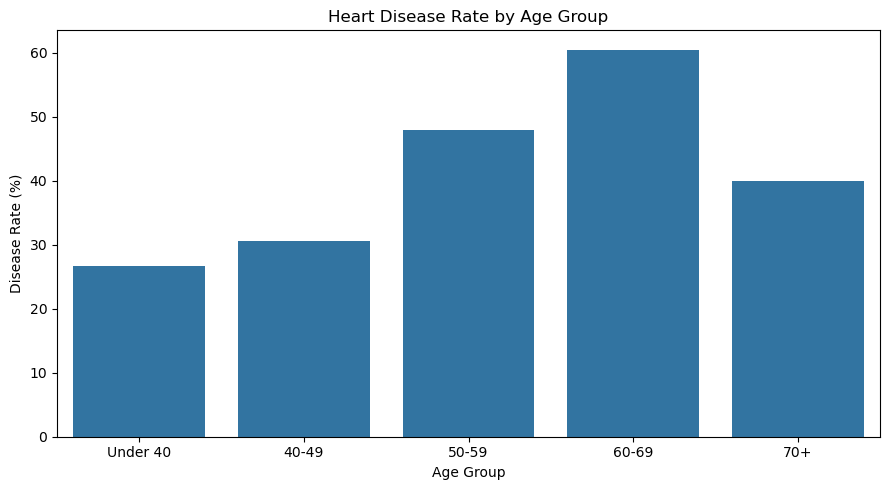

In [52]:
age_group_analysis = (
    df.groupby("age_group", observed=True)
    .agg(
        total_patients=("target", "count"),
        disease_patients=("target", "sum")
    )
)
age_group_analysis["disease_rate"] = (
    age_group_analysis["disease_patients"]
    / age_group_analysis["total_patients"]
    * 100
)
print(age_group_analysis.round(2))
plt.figure(figsize=(9, 5))
sns.barplot(
    data=age_group_analysis.reset_index(),
    x="age_group",
    y="disease_rate"
)
plt.title("Heart Disease Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Disease Rate (%)")
plt.tight_layout()
plt.show()

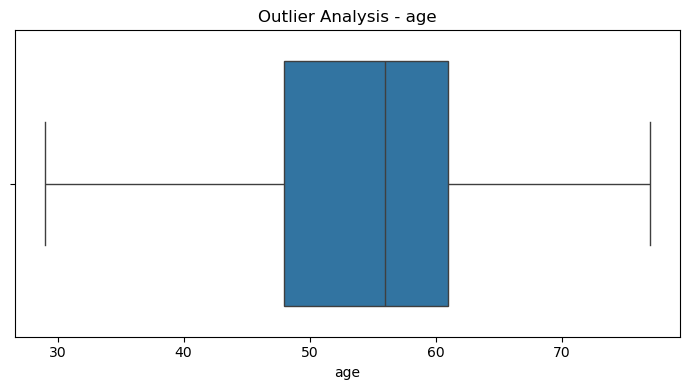

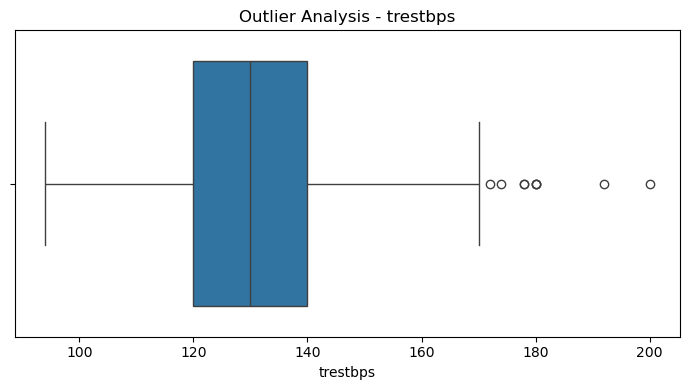

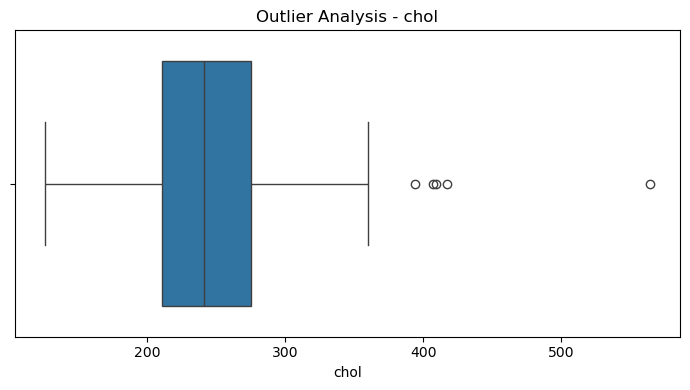

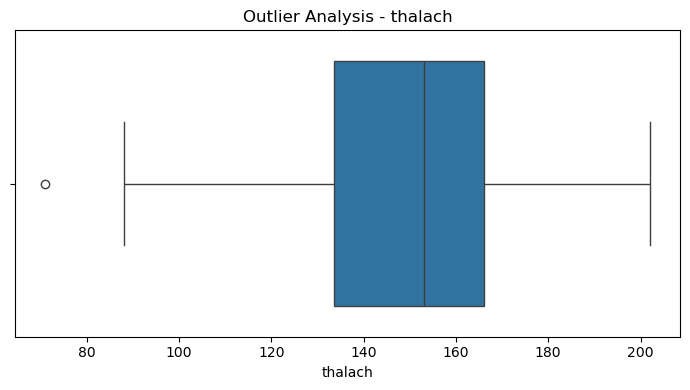

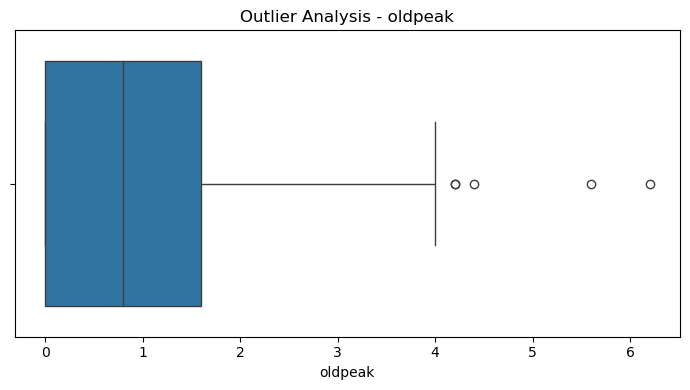

In [54]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]
for column in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df,
        x=column
    )
    plt.title(f"Outlier Analysis - {column}")
    plt.tight_layout()
    plt.show()

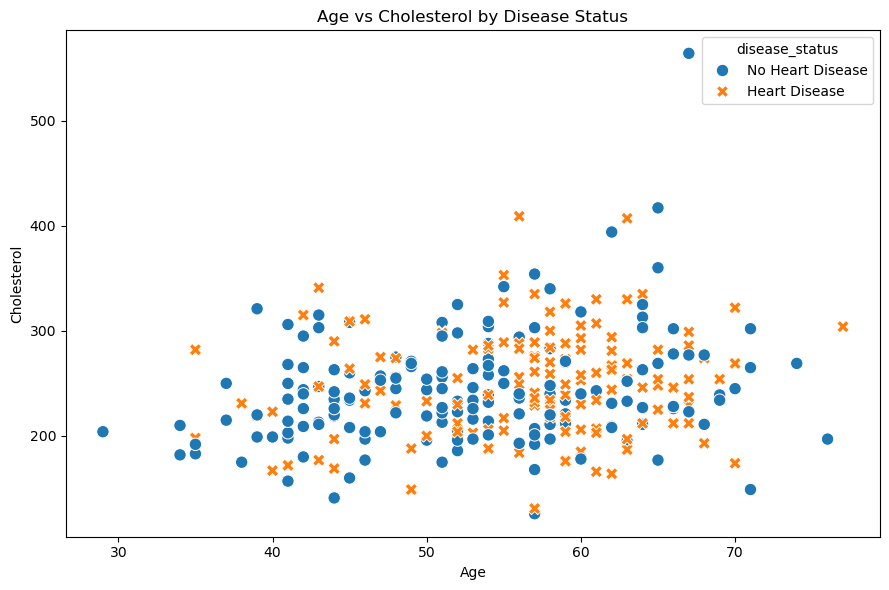

In [56]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="chol",
    hue="disease_status",
    style="disease_status",
    s=80
)
plt.title("Age vs Cholesterol by Disease Status")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.tight_layout()
plt.show()

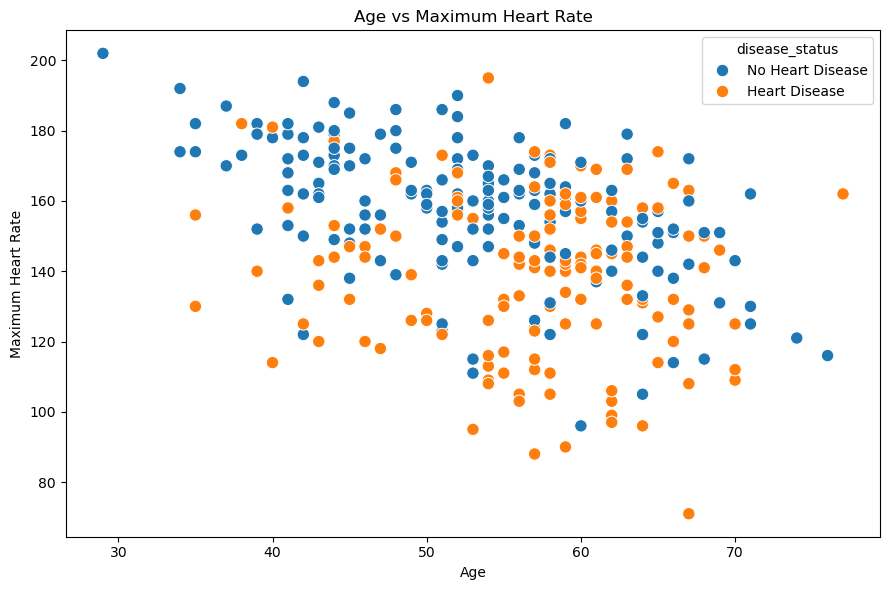

In [58]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="thalach",
    hue="disease_status",
    s=80
)
plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.tight_layout()
plt.show()

In [60]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print("\nTotal Patients:")
print(len(df))
print("\nDisease Distribution:")
print(df["disease_status"].value_counts())
print("\nAverage Age:")
print(round(df["age"].mean(), 2))
print("\nAverage Cholesterol:")
print(round(df["chol"].mean(), 2))
print("\nAverage Resting Blood Pressure:")
print(round(df["trestbps"].mean(), 2))
print("\nAverage Maximum Heart Rate:")
print(round(df["thalach"].mean(), 2))
print("\nTarget Correlations:")
print(target_correlation)

EDA SUMMARY

Total Patients:
303

Disease Distribution:
disease_status
No Heart Disease    164
Heart Disease       139
Name: count, dtype: int64

Average Age:
54.44

Average Cholesterol:
246.69

Average Resting Blood Pressure:
131.69

Average Maximum Heart Rate:
149.61

Target Correlations:
target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64
